In [ ]:
# Tournament Scheduling MILP in Jupyter Notebook with AMPL
# Install required packages: pip install amplpy pandas numpy matplotlib


%pip install -q amplpy


import pandas as pd
import numpy as np
from amplpy import AMPL, Environment,ampl_notebook, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns


ampl = ampl_notebook(
    modules=["highs", "cbc", "gurobi", "cplex"], # pick from over 20 modules including most commercial and open-source solvers
    license_uuid="caf71c55-8ecf-4310-90e3-f0195364ecce")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 45.7 MB/s eta 0:00:00
Licensed to AMPL Academic Community Edition License for <dimit.chatzistefanou@studio.unibo.it>.


\n================================================================================
TESTING WITH 4 TEAMS
Creating tournament model for 4 teams...
Solving...
Gurobi 12.0.2:   lim:time = 300
Gurobi 12.0.2: infeasible problem
0 simplex iterations

suffix dunbdd OUT;
Solve time: 0.15 seconds
Status: infeasible
No solution found!
\n================================================================================
\n================================================================================
TESTING WITH 6 TEAMS
Creating tournament model for 6 teams...
Solving...
Gurobi 12.0.2:   lim:time = 300
Gurobi 12.0.2: infeasible problem
1258 simplex iterations
1 branching node

suffix dunbdd OUT;
Solve time: 0.18 seconds
Status: infeasible
No solution found!
\n================================================================================
\n================================================================================
TESTING WITH 8 TEAMS
Creating tournament model for 8 teams...
Solving...
Gurobi

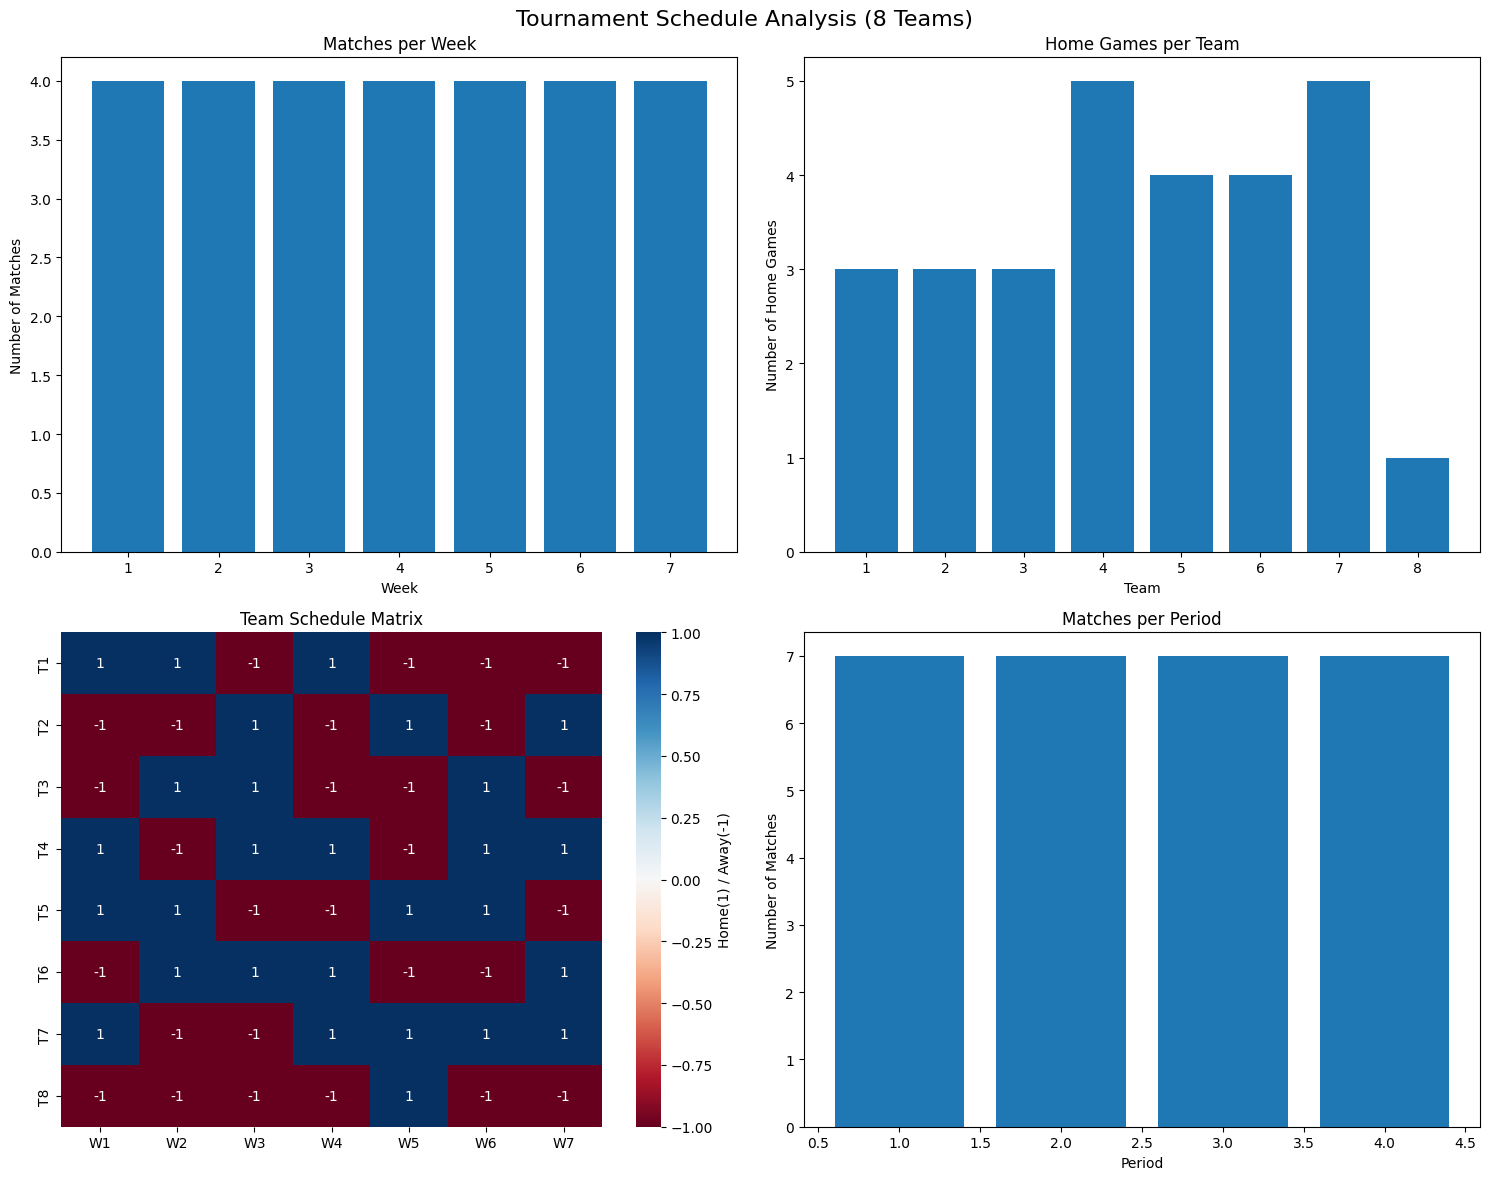

\n================================================================================
\n================================================================================
TESTING WITH 10 TEAMS
Creating tournament model for 10 teams...
Solving...
Gurobi 12.0.2:   lim:time = 300
Gurobi 12.0.2: optimal solution; objective 0
448791 simplex iterations
1407 branching nodes
Solve time: 40.34 seconds
Status: solved
\n============================================================
TOURNAMENT SCHEDULE - 10 TEAMS
Solved in 40.34 seconds
\nMATCH SCHEDULE:
 Match  Week  Period  Home  Away
     1     1       1     1     2
     2     2       1     8     4
     3     3       1     6     3
     4     4       1     8     6
     5     5       1     2     9
     6     6       1     7    10
     7     7       1     5     3
     8     8       1     4     5
     9     9       1     7     9
    10     1       2     3     8
    11     2       2     2    10
    12     3       2     7     8
    13     4       2     4   

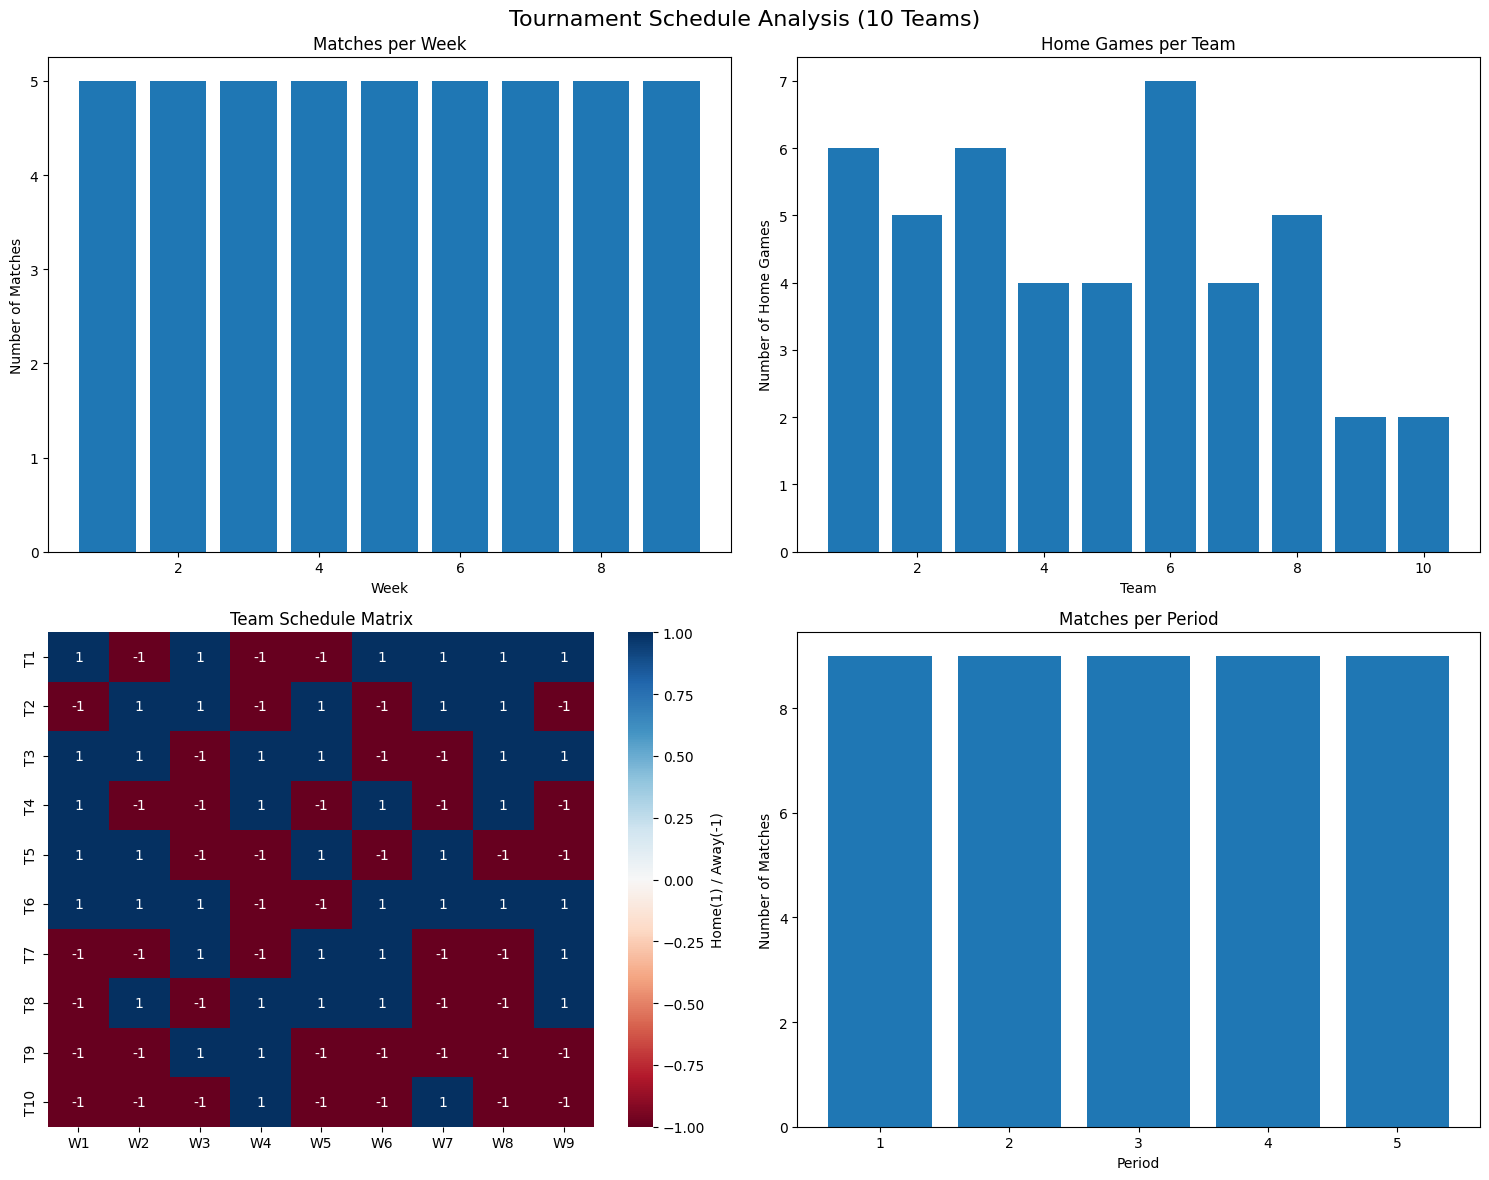

\n================================================================================
\n================================================================================
TESTING WITH 12 TEAMS
Creating tournament model for 12 teams...
Solving...
Gurobi 12.0.2:   lim:time = 300
Gurobi 12.0.2: time limit, without a feasible solution
2.40293e+06 simplex iterations
5413 branching nodes
Solve time: 300.23 seconds
Status: limit
No solution found!
\n================================================================================
\n================================================================================
TESTING WITH 14 TEAMS
Creating tournament model for 14 teams...
Solving...
Gurobi 12.0.2:   lim:time = 300
Gurobi 12.0.2: time limit, without a feasible solution
1.39955e+06 simplex iterations
1430 branching nodes
Solve time: 300.30 seconds
Status: limit
No solution found!
\n================================================================================
\n===================================

In [ ]:


def create_tournament_model(n_teams):

    """
    Create and solve tournament scheduling model for n_teams
    """
    # Clear any existing model
    ampl.reset()

    # Model definition as string
    model_code = f"""
    # Tournament Scheduling MILP in AMPL
    # {n_teams} teams, {n_teams-1} weeks, {n_teams//2} periods per week, 2 slots per period

    # Parameters
    param n := {n_teams};  # Number of teams (must be even)
    param weeks := n - 1;
    param periods := n div 2;
    param total_matches := n * (n - 1) div 2;

    # Sets
    set TEAMS := 1..n;
    set WEEKS := 1..weeks;
    set PERIODS := 1..periods;
    set MATCHES := 1..total_matches;

    # Function to map match number to week and period
    param match_to_week{{m in MATCHES}} := ((m-1) mod weeks) + 1;
    param match_to_period{{m in MATCHES}} := ((m-1) div weeks) + 1;

    # Decision Variables
    # x[i,j,m] = 1 if team i plays at home against team j in match m
    var x{{i in TEAMS, j in TEAMS, m in MATCHES: i != j}} binary;

    # y[i,w,p] = 1 if team i plays in period p of week w
    var y{{TEAMS, WEEKS, PERIODS}} binary;

    # Auxiliary variables for period ordering in first week
    var h{{TEAMS, PERIODS}} binary;

    # Objective (feasibility problem)
    minimize obj: 0;

    # Constraints

    #0. No self play
    #subject to NoSelfPlay{{i in TEAMS, m in MATCHES}}:
    #    x[i,i,m] = 0;

    # 1. Each pair of teams plays exactly once
    subject to unique_pairings{{i in TEAMS, j in TEAMS: i < j}}:
        sum{{m in MATCHES}} (x[i,j,m] + x[j,i,m]) = 1;

    # 2. Each match has exactly one home team and one away team
    subject to match_structure{{m in MATCHES}}:
        sum{{i in TEAMS, j in TEAMS: i != j}} x[i,j,m] = 1;

    # 3. Each team plays exactly once per week
    subject to weekly_play{{i in TEAMS, w in WEEKS}}:
        sum{{p in PERIODS}} y[i,w,p] = 1;

    # 4. Link x and y variables
    subject to link_x_y_home{{i in TEAMS, j in TEAMS, m in MATCHES: i != j}}:
        x[i,j,m] <= y[i, match_to_week[m], match_to_period[m]];

    subject to link_x_y_away{{i in TEAMS, j in TEAMS, m in MATCHES: i != j}}:
        x[i,j,m] <= y[j, match_to_week[m], match_to_period[m]];

    # 5. Each period accommodates exactly 2 teams (one match)
    subject to period_capacity{{w in WEEKS, p in PERIODS}}:
        sum{{i in TEAMS}} y[i,w,p] = 2;

    # 6. Each team plays at most twice in the same period across all weeks
    subject to period_limits{{i in TEAMS, p in PERIODS}}:
        sum{{w in WEEKS}} y[i,w,p] <= 2;

    # 7. Team i appears exactly once in period i (for i <= n/2)
    subject to team_period_constraint{{i in TEAMS: i <= periods}}:
        sum{{w in WEEKS}} y[i,w,i] = 1;





    # ######8. Symmetry Breaking Constraints

    # 8.1 Fix first match: Team 1 plays at home against Team 2 in match 1
    subject to fix_first_match:
        x[1,2,1] = 1;

    # 8.2 Lexicographic ordering on weeks
    subject to week_ordering{{w in 1..(weeks-1)}}:
        sum{{p in PERIODS}} y[1,w,p] >= sum{{p in PERIODS}} y[1,w+1,p];

    # 8.3 Link home team variables for first week
    subject to link_home_vars{{i in TEAMS, p in PERIODS}}:
        h[i,p] = sum{{j in TEAMS, m in MATCHES: j != i and match_to_week[m] = 1 and match_to_period[m] = p}} x[i,j,m];

    # 8.4 Exactly one home team per period in first week
    subject to one_home_per_period{{p in PERIODS}}:
        sum{{i in TEAMS}} h[i,p] = 1;

    # 8.5 Home teams in ascending order across periods in first week
    subject to home_team_ordering{{p in 1..(periods-1)}}:
        sum{{i in 1..n}} i * h[i,p] <= sum{{i in 1..n}} i * h[i,p+1];
    """

    # Load the model
    ampl.eval(model_code)

    return ampl

def solve_tournament(n_teams, solver='gurobi', time_limit=300):
    """
    Solve tournament scheduling problem
    """
    print(f"Creating tournament model for {n_teams} teams...")

    # Create model
    ampl = create_tournament_model(n_teams)

    # Set solver options
    ampl.option['solver'] = solver
    ampl.option['gurobi_options'] = f'timelim={time_limit}'

    # Solve
    print("Solving...")
    import time
    start_time = time.time()
    ampl.solve()
    solve_time = time.time() - start_time

    # Get solution status
    solve_result = ampl.get_value('solve_result')

    print(f"Solve time: {solve_time:.2f} seconds")
    print(f"Status: {solve_result}")

    if solve_result == 'solved':
        return extract_solution(ampl, n_teams, solve_time)
    else:
        print("No solution found!")
        return None

def extract_solution(ampl, n_teams, solve_time):
    """
    Extract and format solution from AMPL
    """
    # Get variables
    x = ampl.get_variable('x')
    y = ampl.get_variable('y')

    # Extract match data
    matches = []
    weeks = n_teams - 1
    periods = n_teams // 2

    for i in range(1, n_teams + 1):
        for j in range(1, n_teams + 1):
            if i != j:
                for m in range(1, n_teams * (n_teams - 1) // 2 + 1):
                    if x[i, j, m].value() > 0.5:  # Binary variable is 1
                        week = ((m - 1) % weeks) + 1
                        period = ((m - 1) // weeks) + 1
                        matches.append({
                            'Match': m,
                            'Week': week,
                            'Period': period,
                            'Home': i,
                            'Away': j
                        })

    # Create DataFrame
    df_matches = pd.DataFrame(matches).sort_values('Match')

    # Create weekly schedule
    weekly_schedule = {}
    for week in range(1, weeks + 1):
        weekly_schedule[f'Week {week}'] = {}
        for period in range(1, periods + 1):
            match = df_matches[(df_matches['Week'] == week) & (df_matches['Period'] == period)]
            if not match.empty:
                home = match.iloc[0]['Home']
                away = match.iloc[0]['Away']
                weekly_schedule[f'Week {week}'][f'Period {period}'] = f"Team {home} vs Team {away}"

    return {
        'matches_df': df_matches,
        'weekly_schedule': weekly_schedule,
        'solve_time': solve_time,
        'n_teams': n_teams
    }

def display_results(solution):
    """
    Display tournament results with nice formatting
    """
    if solution is None:
        return

    df = solution['matches_df']
    weekly = solution['weekly_schedule']

    print(f"\\n{'='*60}")
    print(f"TOURNAMENT SCHEDULE - {solution['n_teams']} TEAMS")
    print(f"Solved in {solution['solve_time']:.2f} seconds")
    print(f"{'='*60}")

    # Display match schedule
    print("\\nMATCH SCHEDULE:")
    print(df.to_string(index=False))

    # Display weekly schedule
    print("\\nWEEKLY SCHEDULE:")
    for week, periods in weekly.items():
        print(f"\\n{week}:")
        for period, match in periods.items():
            print(f"  {period}: {match}")

def visualize_schedule(solution):
    """
    Create visualizations of the tournament schedule
    """
    if solution is None:
        return

    df = solution['matches_df']
    n_teams = solution['n_teams']

    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Tournament Schedule Analysis ({n_teams} Teams)', fontsize=16)

    # 1. Matches per week
    matches_per_week = df['Week'].value_counts().sort_index()
    ax1.bar(matches_per_week.index, matches_per_week.values)
    ax1.set_title('Matches per Week')
    ax1.set_xlabel('Week')
    ax1.set_ylabel('Number of Matches')

    # 2. Home games per team
    home_games = df['Home'].value_counts().sort_index()
    ax2.bar(home_games.index, home_games.values)
    ax2.set_title('Home Games per Team')
    ax2.set_xlabel('Team')
    ax2.set_ylabel('Number of Home Games')

    # 3. Schedule heatmap
    schedule_matrix = np.zeros((n_teams, n_teams - 1))
    for _, row in df.iterrows():
        schedule_matrix[row['Home'] - 1, row['Week'] - 1] = 1
        schedule_matrix[row['Away'] - 1, row['Week'] - 1] = -1

    sns.heatmap(schedule_matrix, annot=True, cmap='RdBu', center=0,
                xticklabels=[f'W{i}' for i in range(1, n_teams)],
                yticklabels=[f'T{i}' for i in range(1, n_teams + 1)],
                ax=ax3, cbar_kws={'label': 'Home(1) / Away(-1)'})
    ax3.set_title('Team Schedule Matrix')

    # 4. Period distribution
    period_dist = df['Period'].value_counts().sort_index()
    ax4.bar(period_dist.index, period_dist.values)
    ax4.set_title('Matches per Period')
    ax4.set_xlabel('Period')
    ax4.set_ylabel('Number of Matches')

    plt.tight_layout()
    plt.show()

def verify_constraints(solution):
    """
    Verify that the solution satisfies all constraints
    """
    if solution is None:
        return

    df = solution['matches_df']
    n_teams = solution['n_teams']

    print(f"\\n{'='*40}")
    print("CONSTRAINT VERIFICATION")
    print(f"{'='*40}")

    # Check 1: Each team plays once per week
    all_good = True
    for team in range(1, n_teams + 1):
        for week in range(1, n_teams):
            games_this_week = len(df[(df['Week'] == week) &
                                   ((df['Home'] == team) | (df['Away'] == team))])
            if games_this_week != 1:
                print(f"❌ Team {team} plays {games_this_week} games in week {week}")
                all_good = False

    if all_good:
        print("✅ Each team plays exactly once per week")

    # Check 2: Each pair plays exactly once
    pairs_played = set()
    for _, row in df.iterrows():
        pair = tuple(sorted([row['Home'], row['Away']]))
        if pair in pairs_played:
            print(f"❌ Teams {pair[0]} and {pair[1]} play more than once")
            all_good = False
        pairs_played.add(pair)

    expected_pairs = n_teams * (n_teams - 1) // 2
    if len(pairs_played) == expected_pairs:
        print("✅ Each pair of teams plays exactly once")
    else:
        print(f"❌ Expected {expected_pairs} unique pairs, got {len(pairs_played)}")
        all_good = False

    # Check 3: Period capacity
    for week in range(1, n_teams):
        for period in range(1, n_teams // 2 + 1):
            matches_in_period = len(df[(df['Week'] == week) & (df['Period'] == period)])
            if matches_in_period != 1:
                print(f"❌ Week {week}, Period {period} has {matches_in_period} matches (should be 1)")
                all_good = False

    if all_good:
        print("✅ Each period has exactly one match")

    print(f"\\nOverall: {'✅ ALL CONSTRAINTS SATISFIED' if all_good else '❌ CONSTRAINT VIOLATIONS FOUND'}")

# Example usage
if __name__ == "__main__":
    # Test with different team sizes
    for n in [4, 6, 8,10,12,14,16]:
        print(f"\\n{'='*80}")
        print(f"TESTING WITH {n} TEAMS")
        print(f"{'='*80}")

        solution = solve_tournament(n, solver='gurobi', time_limit=300)

        if solution:
            display_results(solution)
            verify_constraints(solution)
            visualize_schedule(solution)

        print("\\n" + "="*80)



In [ ]:
# Interactive function for Jupyter users
def run_tournament_scheduler():
    """
    Interactive tournament scheduler for Jupyter notebooks
    """
    print("🏆 Tournament Scheduler")
    print("=" * 50)

    # Get user input
    while True:
        try:
            n_teams = int(input("Enter number of teams (even number, 4-16 recommended): "))
            if n_teams % 2 != 0:
                print("Number of teams must be even!")
                continue
            if n_teams < 4:
                print("Need at least 4 teams!")
                continue
            break
        except ValueError:
            print("Please enter a valid number!")

    # Solve
    solution = solve_tournament(n_teams)

    if solution:
        display_results(solution)
        verify_constraints(solution)

        # Ask if user wants visualization
        viz = input("\\nShow visualizations? (y/n): ").lower()
        if viz == 'y':
            visualize_schedule(solution)

    return solution

# Uncomment the line below to run interactively
 run_tournament_scheduler()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 38)